# 06 — Terrain Derivation

Pre-event optical imagery is a weak forecasting signal: a stable forested
slope and one about to fail look nearly identical from above. Terrain is
what carries the prediction.

Strategy:

| Decision | Choice | Why |
|---|---|---|
| DEM source | Copernicus DEM GLO-30 | Free, global, 30 m, no registration. Best quality open DEM for Sri Lanka. |
| Download method | One regional mosaic, cached | All patches fall in ~4 DEM tiles. Per-patch fetching would repeat the same download thousands of times. |
| Derived layers | slope, hillshade, profile curvature | Steepness, shaded relief (the "contour map" view), and concave hollows where water and debris concentrate. |
| Contour render | generated, not model input | Contours are decoded elevation — lossy. Kept for the ablation and the UI. |
| Alignment | same UTM grid, same 64 px, same bounds | Every terrain pixel matches its optical pixel exactly. |

Output: data/terrain/patches/<id>.tif (3 bands) + contour PNGs

> Copernicus DEM GLO-30 via Microsoft Planetary Computer.

In [3]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer as pc
import pystac_client
import rasterio
from rasterio.enums import Resampling
from rasterio.merge import merge
from rasterio.transform import from_bounds as transform_from_bounds
from rasterio.vrt import WarpedVRT
from rasterio.windows import from_bounds as window_from_bounds
from shapely.geometry import box as shp_box
from tqdm.auto import tqdm

PROJECT_DIR = Path("..").resolve()
COORD_CSV   = PROJECT_DIR / "data" / "coordinates" / "all_coordinates.csv"
TERRAIN_DIR = PROJECT_DIR / "data" / "terrain"
PATCH_DIR   = TERRAIN_DIR / "patches"        # <- terrain GeoTIFFs go HERE
CONTOUR_DIR = TERRAIN_DIR / "contours"
META_DIR    = PROJECT_DIR / "data" / "metadata"
FIG_DIR     = PROJECT_DIR / "outputs" / "figures"
DEM_MOSAIC  = TERRAIN_DIR / "dem_mosaic.tif"

for d in (PATCH_DIR, CONTOUR_DIR, META_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

PATCH_SIZE_M = 640          # must match notebook 05
PATCH_PIXELS = 64
DST_CRS      = "EPSG:32644"
DEM_RES_M    = 30           # native GLO-30 — do not raise this

HILLSHADE_AZIMUTH  = 315.0
HILLSHADE_ALTITUDE = 45.0
CONTOUR_INTERVAL_M = 20

MAKE_CONTOURS = True        # False skips PNG rendering (much faster)
PAD_M = 3000

STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

print(f"patch   : {PATCH_SIZE_M} m / {PATCH_PIXELS} px")
print(f"DEM     : {DEM_RES_M} m native")
print(f"patches : {PATCH_DIR}")

patch   : 640 m / 64 px
DEM     : 30 m native
patches : E:\LandSlide-Prediction\data\terrain\patches


In [4]:
coords = pd.read_csv(COORD_CSV)
assert "label" in coords.columns, "Expected all_coordinates.csv with a label column"
print(f"{len(coords)} locations "
      f"({(coords.label==1).sum()} positive, {(coords.label==0).sum()} negative)")

gdf = gpd.GeoDataFrame(coords, geometry=gpd.points_from_xy(
    coords.longitude, coords.latitude), crs="EPSG:4326").to_crs(DST_CRS)

half = PATCH_SIZE_M / 2
gdf["minx"] = gdf.geometry.x - half
gdf["maxx"] = gdf.geometry.x + half
gdf["miny"] = gdf.geometry.y - half
gdf["maxy"] = gdf.geometry.y + half

locations = gdf[["landslide_id", "label",
                 "minx", "miny", "maxx", "maxy"]].to_dict("records")

w_km = (gdf.maxx.max() - gdf.minx.min() + 2*PAD_M) / 1000
h_km = (gdf.maxy.max() - gdf.miny.min() + 2*PAD_M) / 1000
px_w, px_h = int(w_km*1000/DEM_RES_M), int(h_km*1000/DEM_RES_M)
print(f"\nregion : {w_km:.0f} x {h_km:.0f} km")
print(f"mosaic : {px_w:,} x {px_h:,} px  ({px_w*px_h*4/1e6:.0f} MB in memory)")
assert px_w*px_h*4/1e9 < 2.0, "Mosaic too large — raise DEM_RES_M"

3024 locations (1512 positive, 1512 negative)

region : 166 x 178 km
mosaic : 5,533 x 5,939 px  (131 MB in memory)


In [5]:
if DEM_MOSAIC.exists():
    with rasterio.open(DEM_MOSAIC) as s:
        print(f"cached: {s.width} x {s.height} px @ {s.res[0]:.0f} m "
              f"({DEM_MOSAIC.stat().st_size/1e6:.0f} MB)")
else:
    bounds = (gdf.minx.min()-PAD_M, gdf.miny.min()-PAD_M,
              gdf.maxx.max()+PAD_M, gdf.maxy.max()+PAD_M)
    bbox_wgs = (gpd.GeoSeries([shp_box(*bounds)], crs=DST_CRS)
                .to_crs("EPSG:4326").total_bounds)
    print(f"region bbox (lon/lat): {bbox_wgs.round(3)}")

    cat = pystac_client.Client.open(STAC_URL, modifier=pc.sign_inplace)
    items = list(cat.search(collections=["cop-dem-glo-30"],
                            bbox=bbox_wgs.tolist()).items())
    print(f"{len(items)} DEM tiles — downloading ...")
    assert items, "no DEM coverage for this region"

    vrts, srcs = [], []
    for it in items:
        src = rasterio.open(it.assets["data"].href)
        srcs.append(src)
        vrts.append(WarpedVRT(src, crs=DST_CRS, resampling=Resampling.bilinear))

    dem, transform = merge(vrts, bounds=bounds, res=(DEM_RES_M, DEM_RES_M))
    for v in vrts: v.close()
    for s in srcs: s.close()

    dem = dem[0].astype("float32")

    with rasterio.open(DEM_MOSAIC, "w", driver="GTiff",
                       height=dem.shape[0], width=dem.shape[1], count=1,
                       dtype="float32", crs=DST_CRS, transform=transform,
                       compress="deflate") as dst:
        dst.write(dem, 1)

    print(f"saved: {dem.shape} -> {DEM_MOSAIC.stat().st_size/1e6:.0f} MB")
    print(f"elevation range: {np.nanmin(dem):.0f} - {np.nanmax(dem):.0f} m")

cached: 5533 x 5939 px @ 30 m (114 MB)


In [6]:
with rasterio.open(DEM_MOSAIC) as src:
    mb = src.bounds
    print(f"mosaic bounds: {mb.left:.0f}, {mb.bottom:.0f} -> "
          f"{mb.right:.0f}, {mb.top:.0f}")

outside = gdf[(gdf.minx < mb.left) | (gdf.maxx > mb.right) |
              (gdf.miny < mb.bottom) | (gdf.maxy > mb.top)]
print(f"patches outside the mosaic: {len(outside)}")
assert len(outside) == 0, "Some patches fall outside the DEM — increase PAD_M"
print("CHECKPOINT PASSED — mosaic covers all patches")

mosaic bounds: 384573, 719506 -> 550563, 897676
patches outside the mosaic: 0
CHECKPOINT PASSED — mosaic covers all patches


In [7]:
def read_dem_window(bounds, px=PATCH_PIXELS):
    """Cut a patch-sized DEM window from the cached mosaic and resample to px."""
    with rasterio.open(DEM_MOSAIC) as src:
        win = window_from_bounds(*bounds, transform=src.transform)
        z = src.read(1, window=win, out_shape=(px, px),
                     resampling=Resampling.bilinear,
                     boundless=True, fill_value=np.nan)
    return z.astype(np.float32)


def derive_terrain(z, bounds, px=PATCH_PIXELS):
    """Returns (3, px, px) float32: slope (deg), hillshade (0-255), curvature."""
    res = (bounds[2] - bounds[0]) / px
    z = np.nan_to_num(z, nan=float(np.nanmedian(z)))

    dy, dx = np.gradient(z, res)
    slope_rad = np.arctan(np.hypot(dx, dy))
    slope_deg = np.degrees(slope_rad)

    aspect = np.arctan2(dy, -dx)
    zen = np.radians(90.0 - HILLSHADE_ALTITUDE)
    azi = np.radians(360.0 - HILLSHADE_AZIMUTH + 90.0)
    hs = (np.cos(zen) * np.cos(slope_rad)
          + np.sin(zen) * np.sin(slope_rad) * np.cos(azi - aspect))
    hs = np.clip(hs, 0, 1) * 255.0

    dyy, _ = np.gradient(dy, res)
    _, dxx = np.gradient(dx, res)
    curv = (dxx + dyy) * 100.0

    return np.stack([slope_deg, hs, curv]).astype(np.float32)


def save_terrain(pid, arr, bounds):
    tf = transform_from_bounds(*bounds, arr.shape[2], arr.shape[1])
    path = PATCH_DIR / f"{pid}.tif"
    with rasterio.open(path, "w", driver="GTiff",
                       height=arr.shape[1], width=arr.shape[2], count=3,
                       dtype="float32", crs=DST_CRS, transform=tf,
                       compress="deflate") as dst:
        dst.write(arr)
        dst.descriptions = ("slope_deg", "hillshade", "curvature")
    return str(path)


def save_contour(pid, z, px=256, interval=CONTOUR_INTERVAL_M):
    """Rendered contour map — for the ablation and the UI only, not model input."""
    fig, ax = plt.subplots(figsize=(px/100, px/100), dpi=100)
    ax.set_facecolor("#f7f2d3")
    lo = np.floor(z.min()/interval)*interval
    levels = np.arange(lo, z.max()+interval, interval)
    if len(levels) > 1:
        ax.contour(z, levels=levels, colors="#6b5a20", linewidths=0.5)
        ax.contour(z, levels=levels[::5], colors="#3a2e08", linewidths=1.1)
    ax.set_xlim(0, z.shape[1]); ax.set_ylim(z.shape[0], 0)
    ax.axis("off"); plt.subplots_adjust(0, 0, 1, 1)
    path = CONTOUR_DIR / f"{pid}.png"
    plt.savefig(path, dpi=100); plt.close(fig)
    return str(path)


for fn in ("read_dem_window", "derive_terrain", "save_terrain", "save_contour"):
    assert fn in dir(), f"{fn} missing"
print("all 4 functions defined")

all 4 functions defined


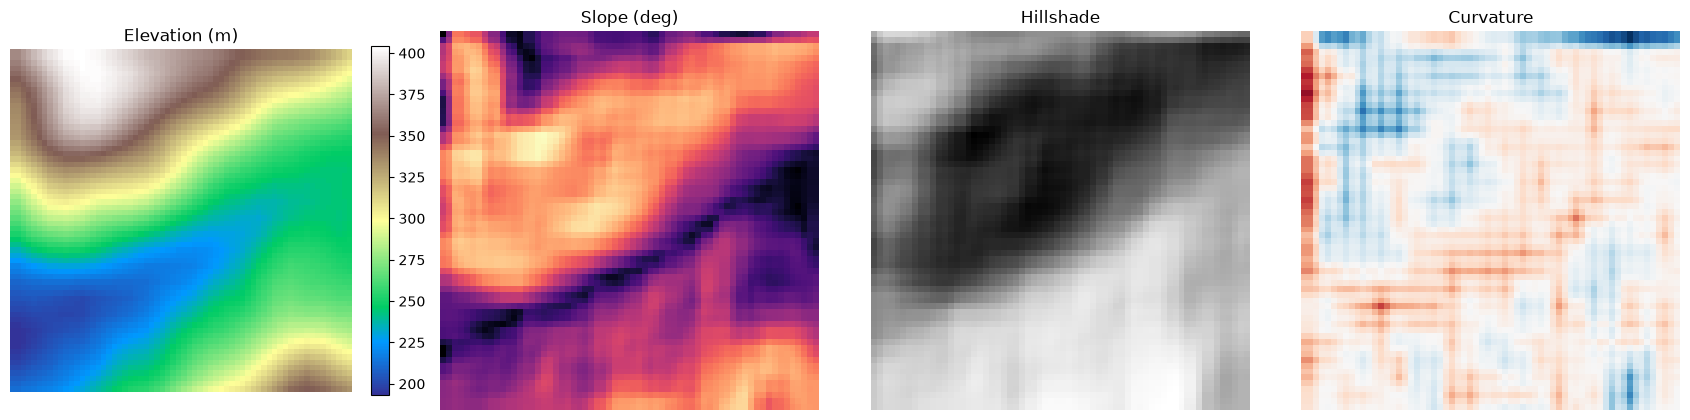

elevation 193-404 m  (relief 211 m)
slope     0.0-38.3 deg (mean 21.3)

CHECKPOINT PASSED


In [8]:
loc = locations[0]
b = (loc["minx"], loc["miny"], loc["maxx"], loc["maxy"])
z = read_dem_window(b)
t = derive_terrain(z, b)

fig, ax = plt.subplots(1, 4, figsize=(17, 4.2))
im0 = ax[0].imshow(z, cmap="terrain");  ax[0].set_title("Elevation (m)")
ax[1].imshow(t[0], cmap="magma");       ax[1].set_title("Slope (deg)")
ax[2].imshow(t[1], cmap="gray");        ax[2].set_title("Hillshade")
m = np.abs(t[2]).max()
ax[3].imshow(t[2], cmap="RdBu_r", vmin=-m, vmax=m); ax[3].set_title("Curvature")
for a in ax: a.axis("off")
plt.colorbar(im0, ax=ax[0], fraction=.046)
plt.tight_layout(); plt.show()

print(f"elevation {z.min():.0f}-{z.max():.0f} m  (relief {np.ptp(z):.0f} m)")
print(f"slope     {t[0].min():.1f}-{t[0].max():.1f} deg (mean {t[0].mean():.1f})")

assert np.isfinite(z).all(), "NaN in elevation — patch outside the mosaic"
assert np.ptp(z) > 1, "Elevation is flat — wrong bounds or CRS"
assert 0 < t[0].mean() < 80, "Implausible slope values"
print("\nCHECKPOINT PASSED")

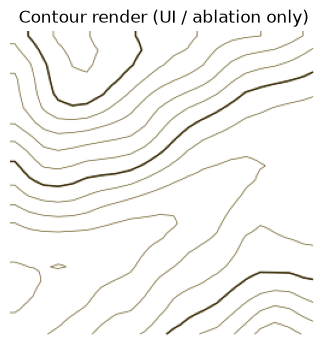

In [9]:
if MAKE_CONTOURS:
    _ = save_contour(loc["landslide_id"], z)
    plt.figure(figsize=(4, 4))
    plt.imshow(plt.imread(CONTOUR_DIR / f"{loc['landslide_id']}.png"))
    plt.axis("off"); plt.title("Contour render (UI / ablation only)")
    plt.show()
else:
    print("MAKE_CONTOURS = False — skipping")

In [10]:
records = []
for loc in tqdm(locations):
    pid = loc["landslide_id"]
    b = (loc["minx"], loc["miny"], loc["maxx"], loc["maxy"])
    try:
        z = read_dem_window(b)
        if not np.isfinite(z).any():
            records.append({"landslide_id": pid, "label": loc["label"],
                            "status": "no_dem"})
            continue
        t = derive_terrain(z, b)
        tif = save_terrain(pid, t, b)
        png = save_contour(pid, z) if MAKE_CONTOURS else ""
        records.append({
            "landslide_id": pid, "label": loc["label"], "status": "success",
            "terrain_tif": tif, "contour_png": png,
            "elev_mean": float(z.mean()), "elev_min": float(z.min()),
            "elev_max": float(z.max()), "relief_m": float(np.ptp(z)),
            "slope_mean": float(t[0].mean()), "slope_max": float(t[0].max()),
            "slope_p90": float(np.percentile(t[0], 90)),
            "curv_mean": float(t[2].mean()), "curv_std": float(t[2].std()),
        })
    except Exception as exc:
        records.append({"landslide_id": pid, "label": loc["label"],
                        "status": "error", "error": repr(exc)})

terrain = pd.DataFrame(records)
terrain.to_csv(META_DIR / "terrain_features.csv", index=False)
print(terrain.status.value_counts())

  0%|          | 0/3024 [00:00<?, ?it/s]

status
success    3024
Name: count, dtype: int64


In [11]:
n_tif = len(list(PATCH_DIR.glob("*.tif")))
n_png = len(list(CONTOUR_DIR.glob("*.png")))
n_ok  = (terrain.status == "success").sum()

print(f"success rows : {n_ok}")
print(f"terrain .tif : {n_tif}   <- in {PATCH_DIR.name}/")
print(f"contour .png : {n_png}")

assert n_tif == n_ok, f"MISMATCH: {n_ok} rows but {n_tif} files"

if (terrain.status != "success").any():
    print("\nfailures:")
    print(terrain[terrain.status != "success"].head(10))
else:
    print("\nCHECKPOINT PASSED — no failures")

success rows : 3024
terrain .tif : 3024   <- in patches/
contour .png : 3024

CHECKPOINT PASSED — no failures


In [12]:
ok = terrain.query("status == 'success'")
pos, neg = ok[ok.label == 1], ok[ok.label == 0]

print(f"positives {len(pos)}   negatives {len(neg)}\n")
print(f"{'feature':<12}{'positive':>12}{'negative':>12}{'diff':>9}")
print("-" * 46)
for f in ["slope_mean", "slope_p90", "slope_max",
          "relief_m", "elev_mean", "curv_std"]:
    a, b_ = pos[f].mean(), neg[f].mean()
    print(f"{f:<12}{a:>12.2f}{b_:>12.2f}{a-b_:>9.2f}")

from scipy.stats import mannwhitneyu
_, p_val = mannwhitneyu(pos.slope_mean, neg.slope_mean)
print(f"\nmean slope, Mann-Whitney U p = {p_val:.2e}")

d = pos.slope_mean.mean() - neg.slope_mean.mean()
if p_val < 0.01 and d > 1.0:
    print(f"\nCHECKPOINT PASSED — positives are {d:.1f} deg steeper. "
          "Terrain carries real signal.")
elif p_val < 0.01:
    print(f"\nSignificant but small ({d:.1f} deg). Hard negatives — "
          "the optical channels will need to do more work.")
else:
    print("\nNO significant slope difference. Investigate before training.")

positives 1512   negatives 1512

feature         positive    negative     diff
----------------------------------------------
slope_mean         21.81       13.22     8.59
slope_p90          33.08       21.93    11.15
slope_max          43.42       31.91    11.51
relief_m          265.80      133.72   132.07
elev_mean         767.56      512.57   254.99
curv_std            0.94        0.65     0.29

mean slope, Mann-Whitney U p = 5.21e-237

CHECKPOINT PASSED — positives are 8.6 deg steeper. Terrain carries real signal.
